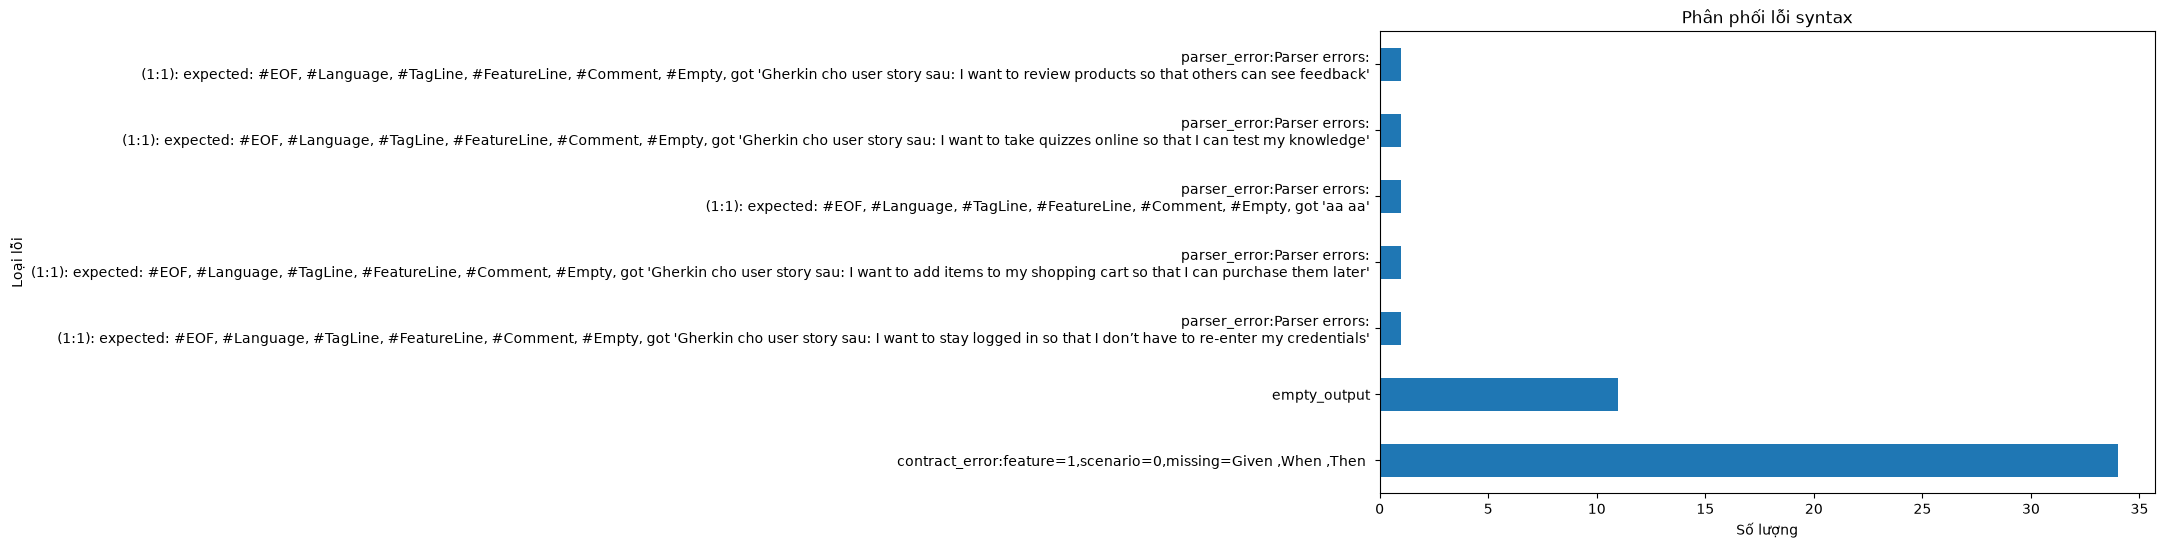

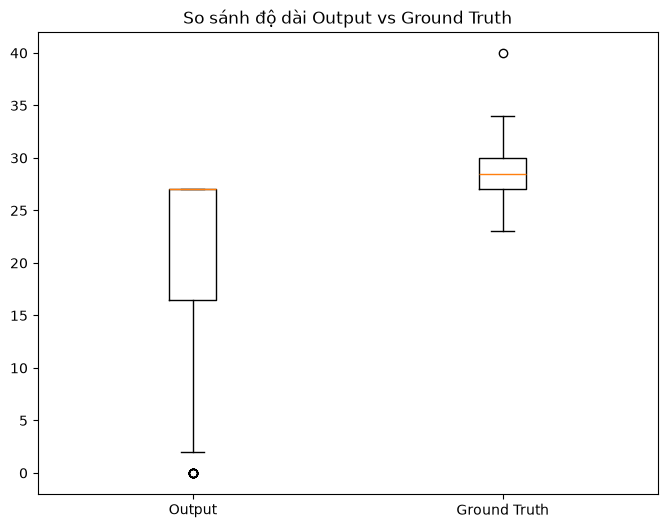

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("full_llm_output.csv")

# Bar chart phân phối lỗi
error_counts = df["syntax_detail"].value_counts()
plt.figure(figsize=(10,6))
error_counts.plot(kind="barh")
plt.title("Phân phối lỗi syntax")
plt.xlabel("Số lượng")
plt.ylabel("Loại lỗi")
plt.show()

# Boxplot độ dài output vs ground truth
df_truth = pd.read_csv(r"D:\long\swt\lab4\nhom_7\data\raw\full_ground_truth.csv")
df["len_output"] = df["generated_gherkin"].fillna("").apply(lambda x: len(str(x).split()))
df_truth["len_truth"] = df_truth["expected_scenario"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,6))
plt.boxplot([df["len_output"], df_truth["len_truth"]], tick_labels=["Output","Ground Truth"])
plt.title("So sánh độ dài Output vs Ground Truth")
plt.show()


In [3]:
import pandas as pd
import os

os.makedirs("results", exist_ok=True)

summary = {
    "N": 50,
    "ValidRate": 0.78,
    "SyntaxPassRate": 0.0,
    "MostCommonError": "contract_error (34/50)"
}

df = pd.DataFrame([summary])
df.to_csv("results/summary.csv", index=False)

# Đọc lại để kiểm tra
print(pd.read_csv("results/summary.csv"))
    

    N  ValidRate  SyntaxPassRate         MostCommonError
0  50       0.78             0.0  contract_error (34/50)


In [2]:
import os
print(os.path.exists("results/summary.csv"))
print(os.path.getsize("results/summary.csv"))


True
80


In [4]:
import pandas as pd
df = pd.read_csv("full_llm_output.csv")
print("Tổng số mẫu:", len(df))
print("Tỷ lệ VALID:", (df["record_status"]=="VALID").mean()*100, "%")
print("Tỷ lệ syntax_pass:", df["syntax_pass"].mean()*100, "%")
print("Các lỗi phổ biến:\n", df["syntax_detail"].value_counts())


Tổng số mẫu: 50
Tỷ lệ VALID: 78.0 %
Tỷ lệ syntax_pass: 0.0 %
Các lỗi phổ biến:
 syntax_detail
contract_error:feature=1,scenario=0,missing=Given ,When ,Then                                                                                                                                                           34
empty_output                                                                                                                                                                                                            11
parser_error:Parser errors:\n(1:1): expected: #EOF, #Language, #TagLine, #FeatureLine, #Comment, #Empty, got 'Gherkin cho user story sau: I want to stay logged in so that I don’t have to re-enter my credentials'      1
parser_error:Parser errors:\n(1:1): expected: #EOF, #Language, #TagLine, #FeatureLine, #Comment, #Empty, got 'Gherkin cho user story sau: I want to add items to my shopping cart so that I can purchase them later'     1
parser_error:Parser errors:\n(